<a href="https://colab.research.google.com/github/ash2079/BML-/blob/main/Basics_of_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

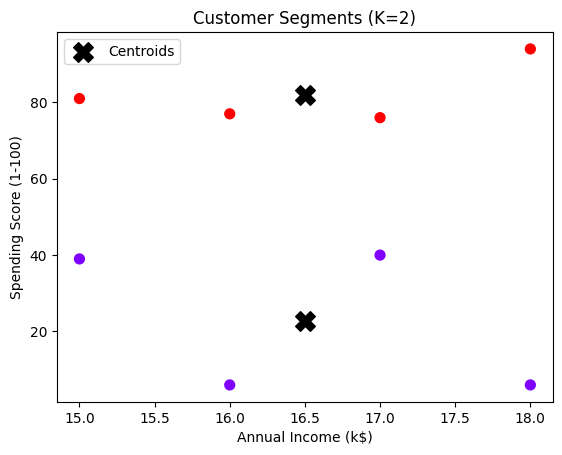

In [ ]:
#exp 7 implement k means model for marketing company
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans

data = {
    'CustomerID': [1, 2, 3, 4, 5, 6, 7, 8],
    'Age': [19, 21, 20, 23, 31, 22, 35, 23],
    'AnnualIncome': [15, 15, 16, 16, 17, 17, 18, 18],
    'SpendingScore': [39, 81, 6, 77, 40, 76, 6, 94],
}
df = pd.DataFrame(data)

X = df[['AnnualIncome', 'SpendingScore']]

kmeans = KMeans(n_clusters=2, init='k-means++', random_state=42)
df['Cluster'] = kmeans.fit_predict(X)

plt.scatter(
    X['AnnualIncome'],
    X['SpendingScore'],
    c=df['Cluster'],
    cmap='rainbow',
    s=50,
)
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    color='black',
    marker='X',
    s=200,
    label='Centroids',
)

plt.title('Customer Segments (K=2)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

   Attendance  StudyHours  PreviousMarks  AssignmentScore  InternalMarks  \
0          90           3             75               85             80   
1          85           2             68               72             70   
2          60           1             35               45             40   
3          75           2             55               65             60   
4          55           1             30               40             35   
5          95           4             88               90             85   
6          65           1             42               50             45   
7          80           3             70               75             72   

  Result  
0   Pass  
1   Pass  
2   Fail  
3   Pass  
4   Fail  
5   Pass  
6   Fail  
7   Pass  
[1 1]
[1 1]
1.0
[[0 0]
 [0 2]]
classfication report
              precision    recall  f1-score   support

        Fail       0.00      0.00      0.00         0
        Pass       1.00      1.00      1.00         2



<function matplotlib.pyplot.show(close=None, block=None)>

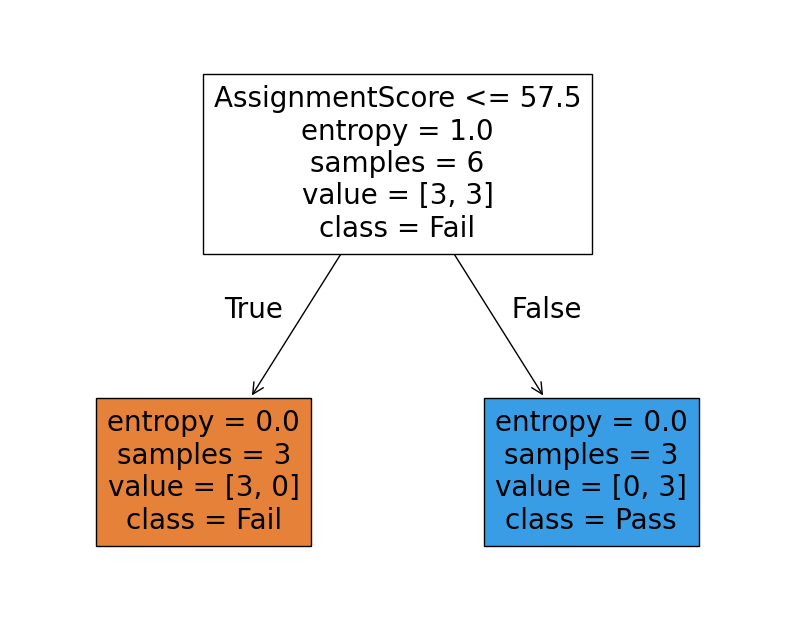

In [ ]:
#exp 6 implement decision tree classification model

from sklearn.metrics.cluster import entropy
from sklearn import model_selection
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor ,plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

data = {
    "Attendance": [90, 85, 60, 75, 55, 95, 65, 80],
    "StudyHours": [3, 2, 1, 2, 1, 4, 1, 3],
    "PreviousMarks": [75, 68, 35, 55, 30, 88, 42, 70],
    "AssignmentScore": [85, 72, 45, 65, 40, 90, 50, 75],
    "InternalMarks": [80, 70, 40, 60, 35, 85, 45, 72],
    "Result": ["Pass", "Pass", "Fail", "Pass",
               "Fail", "Pass", "Fail", "Pass"]
}
df = pd.DataFrame(data)
print(df)
X = df[["Attendance","StudyHours","PreviousMarks","AssignmentScore","InternalMarks"]]
y = df["Result"]

y=y.map({'Fail':0,"Pass":1})

X_train,X_test,y_train,y_test= train_test_split(
    X,y,
    test_size=0.25,
    random_state =42
)

model = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)
model.fit(X_train,y_train)

y_pred =model.predict(X_test)
accuracy = accuracy_score(y_test,y_pred)

print(y_test.values)
print(y_pred)
print(accuracy)
print(confusion_matrix(y_test,y_pred, labels=[0, 1]))
print("classfication report")
print(classification_report(
    y_test,
    y_pred,
    labels=[0, 1],
    target_names=["Fail","Pass"],
    zero_division =0
))
plt.figure(figsize=(10,8))
plot_tree(
    model,
    feature_names =X.columns,
    class_names=["Fail","Pass"],
    filled =True
)
plt.show



In [ ]:
#exp 5 Knn: Breast Cancer
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler


data = load_breast_cancer()

X,y = data.data,data.target

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred))
print('\nClassification Report:\n', classification_report(y_test, y_pred))


Confusion Matrix:
 [[40  3]
 [ 3 68]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.93      0.93        43
           1       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



In [ ]:
# Experiment 4: Logistic Regression

import pandas as pd

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

iris = load_iris()

df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Create target
# 0 = Setosa
# 1 = Not Setosa
df["target"] = (iris.target != 0).astype(int)

print(df.head())

# Separate input and target
X = df[iris.feature_names]
y = df["target"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Logistic Regression model
model = LogisticRegression(max_iter=200)

# Train the model
model.fit(X_train, y_train)

# predictions
y_pred = model.predict(X_test)

# accuracy
accuracy = accuracy_score(y_test, y_pred)

print("\nPredictions:", y_pred)
print("Actual:", y_test.values)
print("Accuracy:", accuracy)

# Predict a new flower
new_flower = [[5.1, 3.5, 1.4, 0.2]]

prediction = model.predict(new_flower)
probability = model.predict_proba(new_flower)

print("For the new flower:")
print("Prediction:", prediction[0])
print("Probability:", probability[0])

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  

Predictions: [1 0 1 1 1 0 1 1 1 1 1 0 0 0 0 1 1 1 1 1 0 1 0 1 1 1 1 1 0 0]
Actual: [1 0 1 1 1 0 1 1 1 1 1 0 0 0 0 1 1 1 1 1 0 1 0 1 1 1 1 1 0 0]
Accuracy: 1.0
For the new flower:
Prediction: 0
Probability: [0.97989495 0.02010505]


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [ ]:
 #exp4 Logistic Regression
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Create dataset
data = {
    "Hours": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "Pass":  [0, 0, 0, 0, 1, 1, 1, 1, 1, 1]
}

df = pd.DataFrame(data)

# Separate input and target
X = df[["Hours"]]
y = df["Pass"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Create model
model = LogisticRegression()

# Train model
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Predictions:", y_pred)
print("Actual:", y_test.values)
print("Accuracy:", accuracy)

# Test a new student
hours = [[7]]

prediction = model.predict(hours)
probability = model.predict_proba(hours)

print("\nFor 7 hours of study:")
print("Prediction:", prediction[0])
print("Probability:", probability[0])

Predictions: [1 0]
Actual: [1 0]
Accuracy: 1.0

For 7 hours of study:
Prediction: 1
Probability: [0.05366761 0.94633239]


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


First 5 rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Model Coefficient (Slope):
1.8339625990203465

Model Intercept:
-6.927127731475695

Actual vs Predicted:
    Actual  Predicted
0      4.7   4.260044
1      1.7   3.526459
2      6.9   7.194384
3      4.5   4.076648
4      4.8   5.543818
5      1.5   2.976270
6      3.6   3.343063
7      5.1   5.727214
8      4.5   4.443440
9      3.9   3.709855
10     5.1   4.993629
11     1.4   1.875893
12     1.3   3.159667
13     1.5   2.059289
14     1.5   2.426082
15     4.7   4.626837
16     5.8   4.993629
17     3.9   3.343063
18    

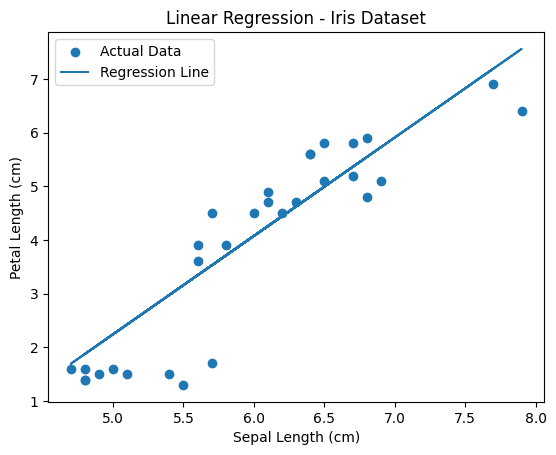

In [ ]:
# Exp3 Linear Regression

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

print("First 5 rows:")
print(df.head())

X = df[['sepal length (cm)']]
y = df['petal length (cm)']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("\nModel Coefficient (Slope):")
print(model.coef_[0])

print("\nModel Intercept:")
print(model.intercept_)


print("\nActual vs Predicted:")
result = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

print(result)

mse = mean_squared_error(y_test, y_pred)

print("\nMean Squared Error:")
print(mse)

r2 = r2_score(y_test, y_pred)

print("\nR-squared:")
print(r2)

plt.scatter(X_test, y_test, label="Actual Data")

plt.plot(
    X_test,
    y_pred,
    label="Regression Line"
)

plt.xlabel("Sepal Length (cm)")
plt.ylabel("Petal Length (cm)")
plt.title("Linear Regression - Iris Dataset")

plt.legend()
plt.show()

In [31]:
#exp2 Data preprocessing
import pandas as pd
from sklearn.preprocessing import LabelEncoder,MinMaxScaler

data = {
    "Salary" : [25000,28000,13000,None],
    "Course":['cse','mechanical',None,'electrical'],
    "Age":[18,None,22,19]
}
df = pd.DataFrame(data)
print(df)

print("\nMissing Values:")
print(df.isnull().sum())

df.fillna(({'Age':df['Age'].mean()}),inplace =True)
df.fillna(({'Salary':df['Salary'].mean()}),inplace =True)

encoder = LabelEncoder()
df['Course'] = encoder.fit_transform(df['Course'])

print("\nDataset after Labelencoding Course:")
print(df)

scaler = MinMaxScaler()
df[['Age', 'Salary']] = scaler.fit_transform(df[['Age', 'Salary']])

print("\nFinal Processed Dataset:")
print(df)



    Salary      Course   Age
0  25000.0         cse  18.0
1  28000.0  mechanical   NaN
2  13000.0        None  22.0
3      NaN  electrical  19.0

Missing Values:
Salary    1
Course    1
Age       1
dtype: int64

Dataset after Labelencoding Course:
    Salary  Course        Age
0  25000.0       0  18.000000
1  28000.0       2  19.666667
2  13000.0       3  22.000000
3  22000.0       1  19.000000

Final Processed Dataset:
   Salary  Course       Age
0     0.8       0  0.000000
1     1.0       2  0.416667
2     0.0       3  1.000000
3     0.6       1  0.250000


In [30]:
#exp1
import pandas as pd
data = pd.read_csv("student.csv")

print(data.head())
print(data.info())

   student_id  gender  study_time_hours  attendance_percent  sleep_hours  \
0           1    Male               4.0                98.0          6.5   
1           2  Female               6.3               100.0          5.7   
2           3    Male               4.9                85.3          7.9   
3           4    Male               2.6                77.5          8.0   
4           5    Male               2.2                89.6          4.6   

  parental_education internet_access extracurricular_activities part_time_job  \
0          Bachelors             Yes                        Yes            No   
1        High School             Yes                        Yes           Yes   
2          Bachelors             Yes                         No           Yes   
3                NaN             Yes                        Yes            No   
4          Bachelors             Yes                         No           Yes   

   previous_grade  final_exam_score final_grade  
0     